<a href="https://colab.research.google.com/github/AlapatiAbhinavChowdhary/sklearn-wine-random-forest/blob/main/wine.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd                 # For dataframes
import numpy as np                  # For numerical operations
import seaborn as sns               # For advanced plotting
import matplotlib.pyplot as plt     # For basic plotting
from sklearn.datasets import load_wine # The specific dataset

In [2]:
# Load the dataset object
wine = load_wine()

# Convert to DataFrame
df = pd.DataFrame(data=wine.data, columns=wine.feature_names)

# Add the target column (the class of wine: 0, 1, or 2)
df['target'] = wine.target

# Inspect the first 5 rows
print(df.head())

   alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
0    14.23        1.71  2.43               15.6      127.0           2.80   
1    13.20        1.78  2.14               11.2      100.0           2.65   
2    13.16        2.36  2.67               18.6      101.0           2.80   
3    14.37        1.95  2.50               16.8      113.0           3.85   
4    13.24        2.59  2.87               21.0      118.0           2.80   

   flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity   hue  \
0        3.06                  0.28             2.29             5.64  1.04   
1        2.76                  0.26             1.28             4.38  1.05   
2        3.24                  0.30             2.81             5.68  1.03   
3        3.49                  0.24             2.18             7.80  0.86   
4        2.69                  0.39             1.82             4.32  1.04   

   od280/od315_of_diluted_wines  proline  target  
0          

In [3]:
# X is everything except the target
X = df.drop('target', axis=1)

# y is only the target
y = df['target']

In [4]:
from sklearn.model_selection import train_test_split

# stratify=y ensures we have an equal mix of wine types in both sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [5]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Fit on training data, then transform both
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [6]:
from sklearn.ensemble import RandomForestClassifier

# Initialize the model
model = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the model using the SCALED training data
model.fit(X_train_scaled, y_train)

RandomForestClassifier(random_state=42)

Accuracy: 1.0


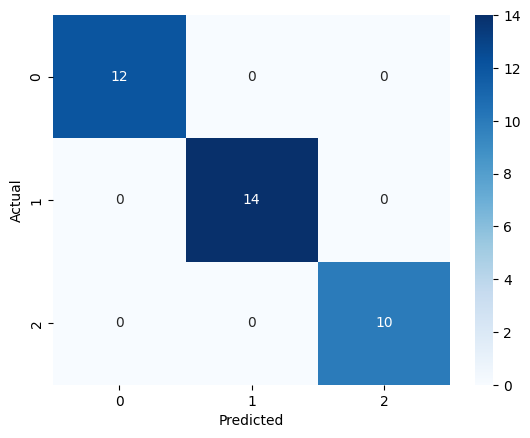

In [7]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Predict
y_pred = model.predict(X_test_scaled)

# 1. Accuracy Score
print(f"Accuracy: {accuracy_score(y_test, y_pred)}")

# 2. Confusion Matrix (Visualizing errors)
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [8]:
from sklearn.model_selection import GridSearchCV

# 1. Define the "Grid" of parameters to test
param_grid = {
    'n_estimators': [50, 100, 200],      # Try 50, 100, and 200 trees
    'max_depth': [None, 10, 20, 30],     # Try different depths
    'min_samples_split': [2, 5]          # Try splitting nodes differently
}

# 2. Initialize the Grid Search
# cv=5 means "Cross-Validation": it splits the training data into 5 parts
# to double-check results, ensuring the score isn't just luck.
grid_search = GridSearchCV(estimator=RandomForestClassifier(random_state=42),
                           param_grid=param_grid,
                           cv=5,
                           verbose=1, # Print progress
                           n_jobs=-1) # Use all computer processors

# 3. Fit the search to the training data
print("Starting Grid Search...")
grid_search.fit(X_train_scaled, y_train)

# 4. Get the results
best_params = grid_search.best_params_
best_score = grid_search.best_score_

print(f"\nBest Parameters Found: {best_params}")
print(f"Best Cross-Validation Accuracy: {best_score:.2f}")

Starting Grid Search...
Fitting 5 folds for each of 24 candidates, totalling 120 fits

Best Parameters Found: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 50}
Best Cross-Validation Accuracy: 0.99


In [9]:
# Use the best model found by GridSearch
best_rf_model = grid_search.best_estimator_

# Predict on the test set
y_pred_tuned = best_rf_model.predict(X_test_scaled)

# Check accuracy
from sklearn.metrics import accuracy_score
tuned_acc = accuracy_score(y_test, y_pred_tuned)

print(f"Tuned Test Set Accuracy: {tuned_acc:.2f}")

# Compare with base model (if you ran the previous code)
# print(f"Improvement: {tuned_acc - base_acc:.2f}")

Tuned Test Set Accuracy: 1.00


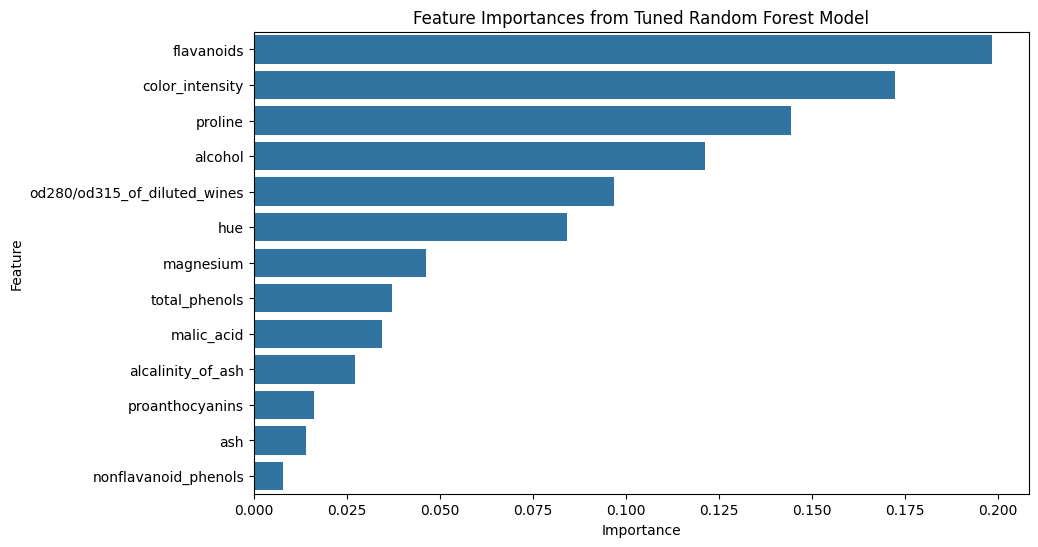

In [12]:
importances = best_rf_model.feature_importances_

feature_names = X.columns

feature_importances = pd.DataFrame({'feature': feature_names, 'importance': importances})

feature_importances = feature_importances.sort_values(by='importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='importance', y='feature', data=feature_importances)
plt.title('Feature Importances from Tuned Random Forest Model')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

In [13]:
from sklearn.pipeline import make_pipeline

# Create a pipeline that does Scaling -> Modeling in one go
pipeline = make_pipeline(StandardScaler(), RandomForestClassifier(n_estimators=100, random_state=42))

# Fit the entire pipeline on raw training data
pipeline.fit(X_train, y_train)  # Note: We use X_train, NOT X_train_scaled

# Score it
accuracy = pipeline.score(X_test, y_test)
print(f"Pipeline Accuracy: {accuracy:.2f}")

Pipeline Accuracy: 1.00


In [14]:
import joblib

# 1. Save the pipeline to a file named 'wine_classifier.pkl'
joblib.dump(pipeline, 'wine_classifier.pkl')
print("Model saved successfully!")

# --- SIMULATING A NEW DAY / NEW SCRIPT ---

# 2. Load the model back
loaded_model = joblib.load('wine_classifier.pkl')

# 3. Predict on a "New" Sample (Simulated raw data)
# Let's grab a random row from the test set to pretend it's new wine
sample_wine = X_test.iloc[0:1]

prediction = loaded_model.predict(sample_wine)
print(f"\nPredicted Class: {prediction[0]}")
print(f"Actual Class: {y_test.iloc[0]}")

Model saved successfully!

Predicted Class: 0
Actual Class: 0
